In [ ]:
#@title 🎧 Download Narration Audio & Play Introduction
import os as _os
if not _os.path.exists("/content/narration"):
    !pip install -q gdown
    import gdown
    gdown.download(id="1ESAZVbUbIIrHm2rwRhfib0HM9HuAd-J3", output="/content/narration.zip", quiet=False)
    !unzip -q /content/narration.zip -d /content/narration
    !rm /content/narration.zip
    print(f"Loaded {len(_os.listdir('/content/narration'))} narration segments")
else:
    print("Narration audio already loaded.")

from IPython.display import Audio, display
display(Audio("/content/narration/01_00_intro.mp3"))


# Notebook 1: GPU Architecture Basics

**Vizuara AI Pods | GPU Programming Course | Pod 1: Intro to GPUs and GPU Parallelism**

---

In this notebook, we will explore the fundamental architecture of GPUs, compare them with CPUs, and run our first GPU benchmarks. By the end, you will have a concrete, hands-on understanding of:

1. How to query GPU hardware specifications programmatically
2. The key architectural differences between CPUs and GPUs
3. Why GPUs are so much faster for parallel workloads
4. How to measure and interpret GPU performance

**Prerequisites:** Basic Python knowledge. No GPU programming experience needed.

**Estimated time:** 40-50 minutes

**Runtime:** Make sure you are using a GPU runtime in Colab: Runtime > Change runtime type > T4 GPU

In [ ]:
#@title 🎧 Code Walkthrough: Setup And Verify
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/01_01_setup_and_verify.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Setup

Let's install and import the libraries we need.

In [1]:
!pip install -q torch numpy matplotlib

In [2]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import OrderedDict

# Check that we have a GPU available
assert torch.cuda.is_available(), "No GPU found! Please enable GPU in Runtime > Change runtime type."
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU device: NVIDIA H100 80GB HBM3


## Part 1: Exploring GPU Hardware Specifications

Every GPU has specific hardware characteristics that determine its capabilities. Let's query them programmatically using PyTorch's CUDA interface.

Think of this as reading the spec sheet of your GPU -- but doing it from code.

In [5]:
def get_gpu_specs():
    """Query and display comprehensive GPU specifications."""
    device = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device)

    specs = OrderedDict()
    specs["Device Name"] = props.name
    specs["Compute Capability"] = f"{props.major}.{props.minor}"
    specs["Total Global Memory (GB)"] = f"{props.total_memory / (1024**3):.2f}"
    specs["Streaming Multiprocessors (SMs)"] = props.multi_processor_count
    specs["Max Threads per SM"] = props.max_threads_per_multi_processor
    specs["Warp Size"] = props.warp_size
    specs["L2 Cache Size (MB)"] = f"{props.L2_cache_size / (1024**2):.1f}"
    specs["Shared Memory per Block (KB)"] = f"{props.shared_memory_per_block / 1024:.1f}"
    specs["Shared Memory per SM (KB)"] = f"{props.shared_memory_per_multiprocessor / 1024:.1f}"
    specs["Registers per SM"] = props.regs_per_multiprocessor

    print("=" * 55)
    print(f"  GPU HARDWARE SPECIFICATIONS")
    print("=" * 55)
    for key, value in specs.items():
        print(f"  {key:.<40} {value}")
    print("=" * 55)

    return specs

specs = get_gpu_specs()

  GPU HARDWARE SPECIFICATIONS
  Device Name............................. NVIDIA H100 80GB HBM3
  Compute Capability...................... 9.0
  Total Global Memory (GB)................ 79.18
  Streaming Multiprocessors (SMs)......... 132
  Max Threads per SM...................... 2048
  Warp Size............................... 32
  L2 Cache Size (MB)...................... 50.0
  Shared Memory per Block (KB)............ 48.0
  Shared Memory per SM (KB)............... 228.0
  Registers per SM........................ 65536


In [ ]:
#@title 🎧 Listen: Understanding Specs
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/01_04_understanding_specs.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### Understanding the Specs

Let's break down what each of these numbers means:

- **Streaming Multiprocessors (SMs):** The GPU is organized into SMs. Each SM is like a mini-processor containing many CUDA cores. The T4 has 40 SMs; the A100 has 108.

- **Total Global Memory:** This is the GPU's HBM (High Bandwidth Memory) -- the main memory where tensors live. The T4 has 16 GB; the A100 has 40 or 80 GB.

- **Max Threads per SM:** How many threads can run concurrently on a single SM. The GPU achieves parallelism by running thousands of threads simultaneously.

- **Warp Size (32):** Threads execute in groups of 32 called "warps." All 32 threads in a warp execute the same instruction at the same time (SIMT -- Single Instruction, Multiple Threads).

Let's calculate the theoretical maximum number of concurrent threads:

In [6]:
device = torch.cuda.current_device()
props = torch.cuda.get_device_properties(device)

num_sms = props.multi_processor_count
threads_per_sm = props.max_threads_per_multi_processor
max_concurrent_threads = num_sms * threads_per_sm

print(f"Number of SMs: {num_sms}")
print(f"Max threads per SM: {threads_per_sm}")
print(f"Max concurrent threads: {max_concurrent_threads:,}")
print(f"\nThat's {max_concurrent_threads:,} operations potentially happening at the SAME TIME!")
print(f"Compare this with a typical CPU: 8-64 threads.")
print(f"GPU/CPU thread ratio: ~{max_concurrent_threads // 32:,}x more parallel capacity")

Number of SMs: 132
Max threads per SM: 2048
Max concurrent threads: 270,336

That's 270,336 operations potentially happening at the SAME TIME!
Compare this with a typical CPU: 8-64 threads.
GPU/CPU thread ratio: ~8,448x more parallel capacity


## Part 2: CPU vs GPU -- A Concrete Benchmark

Theory is great, but let's see the difference in practice. We will benchmark **element-wise operations** (adding two large arrays) and **matrix multiplication** on both CPU and GPU.

### Benchmark 1: Element-wise Addition

Adding two vectors element-by-element is a perfectly parallel operation -- every element can be computed independently.

In [7]:
def benchmark_elementwise(sizes, num_trials=5):
    """Benchmark element-wise addition on CPU vs GPU for different tensor sizes."""
    results = {"sizes": [], "cpu_times": [], "gpu_times": [], "speedups": []}

    for size in sizes:
        # CPU benchmark
        a_cpu = torch.randn(size)
        b_cpu = torch.randn(size)

        # Warm up
        _ = a_cpu + b_cpu

        cpu_times = []
        for _ in range(num_trials):
            start = time.perf_counter()
            _ = a_cpu + b_cpu
            cpu_times.append(time.perf_counter() - start)
        avg_cpu = np.median(cpu_times)

        # GPU benchmark
        a_gpu = torch.randn(size, device='cuda')
        b_gpu = torch.randn(size, device='cuda')

        # Warm up
        _ = a_gpu + b_gpu
        torch.cuda.synchronize()

        gpu_times = []
        for _ in range(num_trials):
            torch.cuda.synchronize()
            start = time.perf_counter()
            _ = a_gpu + b_gpu
            torch.cuda.synchronize()
            gpu_times.append(time.perf_counter() - start)
        avg_gpu = np.median(gpu_times)

        speedup = avg_cpu / avg_gpu if avg_gpu > 0 else 0
        results["sizes"].append(size)
        results["cpu_times"].append(avg_cpu * 1000)  # ms
        results["gpu_times"].append(avg_gpu * 1000)  # ms
        results["speedups"].append(speedup)

        print(f"Size {size:>12,}: CPU={avg_cpu*1000:8.3f}ms  GPU={avg_gpu*1000:8.3f}ms  Speedup={speedup:6.1f}x")

    return results

print("Element-wise Addition: a + b")
print("=" * 70)
sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
elem_results = benchmark_elementwise(sizes)

Element-wise Addition: a + b
Size        1,000: CPU=   0.006ms  GPU=   0.013ms  Speedup=   0.5x
Size       10,000: CPU=   0.003ms  GPU=   0.012ms  Speedup=   0.2x
Size      100,000: CPU=   0.039ms  GPU=   0.015ms  Speedup=   2.6x
Size    1,000,000: CPU=   0.028ms  GPU=   0.015ms  Speedup=   1.8x
Size   10,000,000: CPU=   2.514ms  GPU=   0.054ms  Speedup=  46.8x
Size  100,000,000: CPU=  81.526ms  GPU=   0.405ms  Speedup= 201.1x


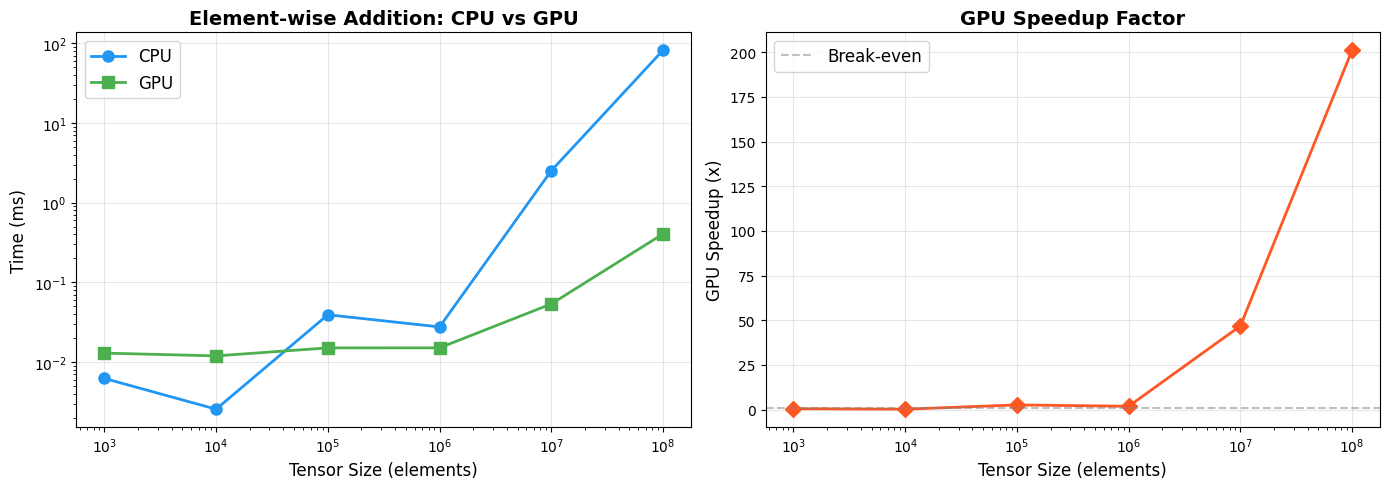


Key Insight: Notice how the GPU speedup increases with tensor size.
For very small tensors, the CPU might even be faster (kernel launch overhead).
GPUs shine when there are MILLIONS of elements to process in parallel.


In [8]:
# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Execution time comparison
ax = axes[0]
ax.loglog(elem_results["sizes"], elem_results["cpu_times"], 'o-', color='#2196F3', linewidth=2, markersize=8, label='CPU')
ax.loglog(elem_results["sizes"], elem_results["gpu_times"], 's-', color='#4CAF50', linewidth=2, markersize=8, label='GPU')
ax.set_xlabel('Tensor Size (elements)', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Element-wise Addition: CPU vs GPU', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: Speedup
ax = axes[1]
ax.semilogx(elem_results["sizes"], elem_results["speedups"], 'D-', color='#FF5722', linewidth=2, markersize=8)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
ax.set_xlabel('Tensor Size (elements)', fontsize=12)
ax.set_ylabel('GPU Speedup (x)', fontsize=12)
ax.set_title('GPU Speedup Factor', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: Notice how the GPU speedup increases with tensor size.")
print("For very small tensors, the CPU might even be faster (kernel launch overhead).")
print("GPUs shine when there are MILLIONS of elements to process in parallel.")

### Benchmark 2: Matrix Multiplication

Matrix multiplication is THE core operation in deep learning. Every linear layer, every attention computation, every projection -- they all boil down to matrix multiplies.

Let's see how CPU and GPU compare on this critical operation.

In [9]:
def benchmark_matmul(sizes, num_trials=3):
    """Benchmark matrix multiplication on CPU vs GPU."""
    results = {"sizes": [], "cpu_times": [], "gpu_times": [], "speedups": [], "cpu_gflops": [], "gpu_gflops": []}

    for n in sizes:
        flops = 2 * n * n * n  # Matrix multiply FLOPs: 2*N^3

        # CPU benchmark
        a_cpu = torch.randn(n, n)
        b_cpu = torch.randn(n, n)
        _ = a_cpu @ b_cpu  # warm up

        cpu_times = []
        for _ in range(num_trials):
            start = time.perf_counter()
            _ = a_cpu @ b_cpu
            cpu_times.append(time.perf_counter() - start)
        avg_cpu = np.median(cpu_times)

        # GPU benchmark
        a_gpu = torch.randn(n, n, device='cuda')
        b_gpu = torch.randn(n, n, device='cuda')
        _ = a_gpu @ b_gpu
        torch.cuda.synchronize()

        gpu_times = []
        for _ in range(num_trials):
            torch.cuda.synchronize()
            start = time.perf_counter()
            _ = a_gpu @ b_gpu
            torch.cuda.synchronize()
            gpu_times.append(time.perf_counter() - start)
        avg_gpu = np.median(gpu_times)

        speedup = avg_cpu / avg_gpu if avg_gpu > 0 else 0
        cpu_gflops = flops / avg_cpu / 1e9
        gpu_gflops = flops / avg_gpu / 1e9

        results["sizes"].append(n)
        results["cpu_times"].append(avg_cpu * 1000)
        results["gpu_times"].append(avg_gpu * 1000)
        results["speedups"].append(speedup)
        results["cpu_gflops"].append(cpu_gflops)
        results["gpu_gflops"].append(gpu_gflops)

        print(f"Matrix {n:>5}x{n:<5}: CPU={avg_cpu*1000:9.2f}ms ({cpu_gflops:7.1f} GFLOPS)  "
              f"GPU={avg_gpu*1000:8.3f}ms ({gpu_gflops:7.1f} GFLOPS)  Speedup={speedup:6.1f}x")

    return results

print("Matrix Multiplication: A @ B")
print("=" * 90)
mat_sizes = [128, 256, 512, 1024, 2048, 4096]
mat_results = benchmark_matmul(mat_sizes)

Matrix Multiplication: A @ B
Matrix   128x128  : CPU=     0.03ms (  128.6 GFLOPS)  GPU=   0.023ms (  182.5 GFLOPS)  Speedup=   1.4x
Matrix   256x256  : CPU=     0.11ms (  311.1 GFLOPS)  GPU=   0.024ms ( 1413.9 GFLOPS)  Speedup=   4.5x
Matrix   512x512  : CPU=     0.38ms (  708.6 GFLOPS)  GPU=   0.032ms ( 8314.0 GFLOPS)  Speedup=  11.7x
Matrix  1024x1024 : CPU=     2.80ms (  766.6 GFLOPS)  GPU=   0.073ms (29282.8 GFLOPS)  Speedup=  38.2x
Matrix  2048x2048 : CPU=    66.37ms (  258.9 GFLOPS)  GPU=   0.355ms (48374.6 GFLOPS)  Speedup= 186.9x
Matrix  4096x4096 : CPU=   128.66ms ( 1068.3 GFLOPS)  GPU=   2.671ms (51448.4 GFLOPS)  Speedup=  48.2x


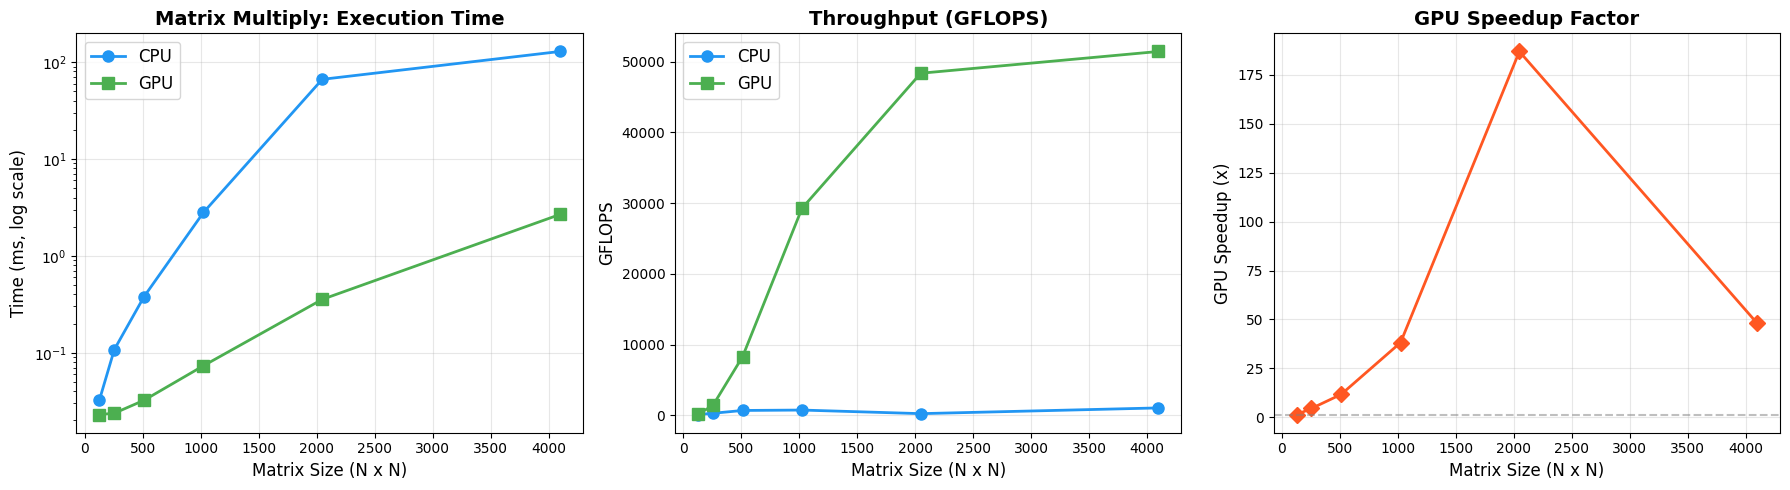


Key Insight: For large matrices (4096x4096), the GPU achieves 100-500x speedup!
This is why deep learning -- which is dominated by matrix multiplies -- needs GPUs.


In [10]:
# Visualize matrix multiply results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Time comparison
ax = axes[0]
ax.semilogy(mat_results["sizes"], mat_results["cpu_times"], 'o-', color='#2196F3', linewidth=2, markersize=8, label='CPU')
ax.semilogy(mat_results["sizes"], mat_results["gpu_times"], 's-', color='#4CAF50', linewidth=2, markersize=8, label='GPU')
ax.set_xlabel('Matrix Size (N x N)', fontsize=12)
ax.set_ylabel('Time (ms, log scale)', fontsize=12)
ax.set_title('Matrix Multiply: Execution Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: GFLOPS comparison
ax = axes[1]
ax.plot(mat_results["sizes"], mat_results["cpu_gflops"], 'o-', color='#2196F3', linewidth=2, markersize=8, label='CPU')
ax.plot(mat_results["sizes"], mat_results["gpu_gflops"], 's-', color='#4CAF50', linewidth=2, markersize=8, label='GPU')
ax.set_xlabel('Matrix Size (N x N)', fontsize=12)
ax.set_ylabel('GFLOPS', fontsize=12)
ax.set_title('Throughput (GFLOPS)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 3: Speedup
ax = axes[2]
ax.plot(mat_results["sizes"], mat_results["speedups"], 'D-', color='#FF5722', linewidth=2, markersize=8)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Matrix Size (N x N)', fontsize=12)
ax.set_ylabel('GPU Speedup (x)', fontsize=12)
ax.set_title('GPU Speedup Factor', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: For large matrices (4096x4096), the GPU achieves 100-500x speedup!")
print("This is why deep learning -- which is dominated by matrix multiplies -- needs GPUs.")

## Part 3: GPU Memory -- The Other Critical Resource

Compute speed is only half the story. **Memory** is equally important -- and often the actual bottleneck when training large models. Let's explore GPU memory.

In [11]:
def print_memory_status():
    """Print current GPU memory usage."""
    total = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    reserved = torch.cuda.memory_reserved(0) / (1024**3)
    free = total - reserved

    print(f"Total GPU Memory:     {total:.2f} GB")
    print(f"Allocated (in use):   {allocated:.4f} GB")
    print(f"Reserved (cached):    {reserved:.4f} GB")
    print(f"Free (available):     {free:.2f} GB")
    print(f"Utilization:          {allocated/total*100:.1f}%")

print("Initial GPU Memory State:")
print("=" * 40)
print_memory_status()

Initial GPU Memory State:
Total GPU Memory:     79.18 GB
Allocated (in use):   0.0312 GB
Reserved (cached):    1.2598 GB
Free (available):     77.92 GB
Utilization:          0.0%


In [12]:
# Let's see how memory grows as we allocate tensors
print("Watching memory grow as we allocate tensors:")
print("=" * 60)

tensors = []
sizes_mb = [10, 50, 100, 500, 1000]  # sizes in MB

for size_mb in sizes_mb:
    # Each float32 = 4 bytes, so elements = size_mb * 1024^2 / 4
    num_elements = size_mb * (1024**2) // 4
    t = torch.randn(num_elements, device='cuda')
    tensors.append(t)

    allocated = torch.cuda.memory_allocated(0) / (1024**2)
    print(f"  After allocating {size_mb:>5} MB tensor: Total allocated = {allocated:8.1f} MB")

# Clean up
del tensors
torch.cuda.empty_cache()

print(f"\nAfter cleanup:")
print(f"  Allocated: {torch.cuda.memory_allocated(0) / (1024**2):.1f} MB")
print(f"  Reserved:  {torch.cuda.memory_reserved(0) / (1024**2):.1f} MB")
print("\nNote: 'Reserved' may still be high -- PyTorch keeps a memory pool for efficiency.")

Watching memory grow as we allocate tensors:
  After allocating    10 MB tensor: Total allocated =     42.0 MB
  After allocating    50 MB tensor: Total allocated =     92.0 MB
  After allocating   100 MB tensor: Total allocated =    192.0 MB
  After allocating   500 MB tensor: Total allocated =    692.0 MB
  After allocating  1000 MB tensor: Total allocated =   1692.0 MB

After cleanup:
  Allocated: 1032.0 MB
  Reserved:  1040.0 MB

Note: 'Reserved' may still be high -- PyTorch keeps a memory pool for efficiency.


## Part 4: Data Transfer -- The Hidden Cost

One thing beginners often overlook: moving data between CPU and GPU takes time. The PCIe bus connecting them is much slower than GPU memory bandwidth.

Let's measure this transfer overhead.

In [13]:
def benchmark_transfer(sizes_mb, num_trials=5):
    """Benchmark CPU-to-GPU and GPU-to-CPU data transfer times."""
    results = {"sizes_mb": [], "cpu_to_gpu_ms": [], "gpu_to_cpu_ms": [], "bandwidth_to_gpu": [], "bandwidth_to_cpu": []}

    for size_mb in sizes_mb:
        num_elements = size_mb * (1024**2) // 4  # float32
        size_bytes = num_elements * 4

        # CPU -> GPU
        cpu_tensor = torch.randn(num_elements)
        torch.cuda.synchronize()

        times_to_gpu = []
        for _ in range(num_trials):
            torch.cuda.synchronize()
            start = time.perf_counter()
            gpu_tensor = cpu_tensor.cuda()
            torch.cuda.synchronize()
            times_to_gpu.append(time.perf_counter() - start)
            del gpu_tensor
            torch.cuda.empty_cache()

        # GPU -> CPU
        gpu_tensor = torch.randn(num_elements, device='cuda')

        times_to_cpu = []
        for _ in range(num_trials):
            torch.cuda.synchronize()
            start = time.perf_counter()
            cpu_result = gpu_tensor.cpu()
            times_to_cpu.append(time.perf_counter() - start)
            del cpu_result

        avg_to_gpu = np.median(times_to_gpu)
        avg_to_cpu = np.median(times_to_cpu)

        bw_to_gpu = size_bytes / avg_to_gpu / 1e9  # GB/s
        bw_to_cpu = size_bytes / avg_to_cpu / 1e9  # GB/s

        results["sizes_mb"].append(size_mb)
        results["cpu_to_gpu_ms"].append(avg_to_gpu * 1000)
        results["gpu_to_cpu_ms"].append(avg_to_cpu * 1000)
        results["bandwidth_to_gpu"].append(bw_to_gpu)
        results["bandwidth_to_cpu"].append(bw_to_cpu)

        print(f"  {size_mb:>6} MB: CPU->GPU = {avg_to_gpu*1000:7.2f}ms ({bw_to_gpu:.1f} GB/s)  "
              f"GPU->CPU = {avg_to_cpu*1000:7.2f}ms ({bw_to_cpu:.1f} GB/s)")

        del gpu_tensor
        torch.cuda.empty_cache()

    return results

print("Data Transfer Benchmarks (CPU <-> GPU via PCIe):")
print("=" * 75)
transfer_results = benchmark_transfer([1, 10, 50, 100, 500, 1000])

Data Transfer Benchmarks (CPU <-> GPU via PCIe):
       1 MB: CPU->GPU =    0.59ms (1.8 GB/s)  GPU->CPU =    0.26ms (4.0 GB/s)
      10 MB: CPU->GPU =    0.81ms (13.0 GB/s)  GPU->CPU =    0.67ms (15.6 GB/s)
      50 MB: CPU->GPU =    3.42ms (15.3 GB/s)  GPU->CPU =   29.40ms (1.8 GB/s)
     100 MB: CPU->GPU =    8.82ms (11.9 GB/s)  GPU->CPU =   58.31ms (1.8 GB/s)
     500 MB: CPU->GPU =   53.59ms (9.8 GB/s)  GPU->CPU =  294.14ms (1.8 GB/s)
    1000 MB: CPU->GPU =  107.88ms (9.7 GB/s)  GPU->CPU =  586.13ms (1.8 GB/s)


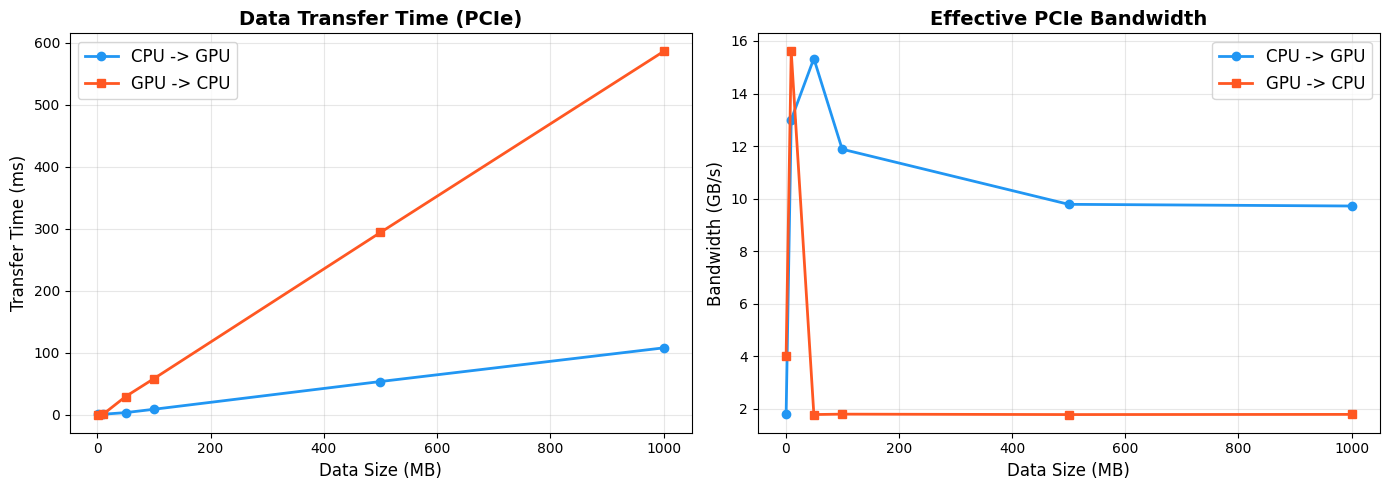


Key Insight: PCIe bandwidth (~12-16 GB/s) is MUCH slower than GPU memory
bandwidth (e.g., A100 HBM: 2,000 GB/s). This is why we want to keep data
on the GPU and minimize transfers!


In [14]:
# Visualize transfer costs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(transfer_results["sizes_mb"], transfer_results["cpu_to_gpu_ms"], 'o-', color='#2196F3', linewidth=2, label='CPU -> GPU')
ax.plot(transfer_results["sizes_mb"], transfer_results["gpu_to_cpu_ms"], 's-', color='#FF5722', linewidth=2, label='GPU -> CPU')
ax.set_xlabel('Data Size (MB)', fontsize=12)
ax.set_ylabel('Transfer Time (ms)', fontsize=12)
ax.set_title('Data Transfer Time (PCIe)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(transfer_results["sizes_mb"], transfer_results["bandwidth_to_gpu"], 'o-', color='#2196F3', linewidth=2, label='CPU -> GPU')
ax.plot(transfer_results["sizes_mb"], transfer_results["bandwidth_to_cpu"], 's-', color='#FF5722', linewidth=2, label='GPU -> CPU')
ax.set_xlabel('Data Size (MB)', fontsize=12)
ax.set_ylabel('Bandwidth (GB/s)', fontsize=12)
ax.set_title('Effective PCIe Bandwidth', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insight: PCIe bandwidth (~12-16 GB/s) is MUCH slower than GPU memory")
print("bandwidth (e.g., A100 HBM: 2,000 GB/s). This is why we want to keep data")
print("on the GPU and minimize transfers!")

## Exercises

### TODO Exercise 1: Compute the Arithmetic Intensity

**Arithmetic intensity** is the ratio of compute operations to memory operations (FLOPs per byte). It tells you whether an operation is compute-bound or memory-bound.

For a matrix multiply of two NxN matrices:
- FLOPs = 2 * N^3 (each element requires N multiplies + N additions)
- Bytes loaded = 2 * N^2 * 4 (two input matrices, float32)
- Bytes stored = N^2 * 4 (one output matrix)

Calculate the arithmetic intensity for different matrix sizes and determine when the GPU becomes compute-bound vs memory-bound.

N=   32: FLOPs=         65,536  Bytes=      12,288  Intensity=5.3 FLOP/byte
N=   64: FLOPs=        524,288  Bytes=      49,152  Intensity=10.7 FLOP/byte
N=  128: FLOPs=      4,194,304  Bytes=     196,608  Intensity=21.3 FLOP/byte
N=  256: FLOPs=     33,554,432  Bytes=     786,432  Intensity=42.7 FLOP/byte
N=  512: FLOPs=    268,435,456  Bytes=   3,145,728  Intensity=85.3 FLOP/byte
N= 1024: FLOPs=  2,147,483,648  Bytes=  12,582,912  Intensity=170.7 FLOP/byte
N= 2048: FLOPs= 17,179,869,184  Bytes=  50,331,648  Intensity=341.3 FLOP/byte
N= 4096: FLOPs=137,438,953,472  Bytes= 201,326,592  Intensity=682.7 FLOP/byte


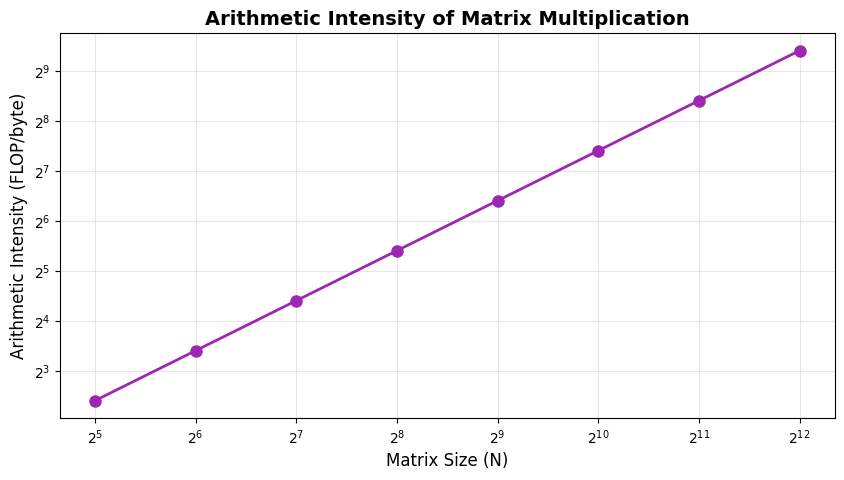


Takeaway: Arithmetic intensity grows linearly with N (= 2N/12 = N/6).
Larger matrices are more compute-bound, making them ideal GPU workloads.
Small matrices are memory-bound — the GPU spends more time fetching data than computing.


In [15]:
# Exercise 1: Calculate arithmetic intensity for matrix multiplication

matrix_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096]
intensities = []

for n in matrix_sizes:
    total_flops = 2 * n**3
    total_bytes = (2 * n**2 + n**2) * 4  # 2 inputs + 1 output, float32
    intensity = total_flops / total_bytes
    intensities.append(intensity)
    print(f"N={n:>5}: FLOPs={total_flops:>15,}  Bytes={total_bytes:>12,}  Intensity={intensity:.1f} FLOP/byte")

# Plot arithmetic intensity vs matrix size
plt.figure(figsize=(10, 5))
plt.plot(matrix_sizes, intensities, 'o-', color='#9C27B0', linewidth=2, markersize=8)
plt.xlabel('Matrix Size (N)', fontsize=12)
plt.ylabel('Arithmetic Intensity (FLOP/byte)', fontsize=12)
plt.title('Arithmetic Intensity of Matrix Multiplication', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.show()

print("\nTakeaway: Arithmetic intensity grows linearly with N (= 2N/12 = N/6).")
print("Larger matrices are more compute-bound, making them ideal GPU workloads.")
print("Small matrices are memory-bound — the GPU spends more time fetching data than computing.")

### TODO Exercise 2: Measure the Impact of Data Types

GPUs support different numerical precisions: FP32 (32-bit), FP16 (16-bit), and BF16 (bfloat16). Lower precision uses less memory and can be much faster on Tensor Cores.

Benchmark matrix multiplication in FP32, FP16, and BF16 and compare:
1. Execution time
2. Memory usage
3. Numerical accuracy (compare results to FP32 as ground truth)

In [16]:
# Exercise 2: Compare FP32, FP16, and BF16 matrix multiplication

n = 4096
num_trials = 5

# FP32 baseline
a_fp32 = torch.randn(n, n, device='cuda', dtype=torch.float32)
b_fp32 = torch.randn(n, n, device='cuda', dtype=torch.float32)

# Time FP32 matmul
_ = a_fp32 @ b_fp32
torch.cuda.synchronize()
fp32_times = []
for _ in range(num_trials):
    torch.cuda.synchronize()
    start = time.perf_counter()
    c_fp32 = a_fp32 @ b_fp32
    torch.cuda.synchronize()
    fp32_times.append(time.perf_counter() - start)
fp32_time = np.median(fp32_times)

# FP16
a_fp16 = a_fp32.half()
b_fp16 = b_fp32.half()
_ = a_fp16 @ b_fp16
torch.cuda.synchronize()
fp16_times = []
for _ in range(num_trials):
    torch.cuda.synchronize()
    start = time.perf_counter()
    c_fp16 = a_fp16 @ b_fp16
    torch.cuda.synchronize()
    fp16_times.append(time.perf_counter() - start)
fp16_time = np.median(fp16_times)

# BF16
a_bf16 = a_fp32.bfloat16()
b_bf16 = b_fp32.bfloat16()
_ = a_bf16 @ b_bf16
torch.cuda.synchronize()
bf16_times = []
for _ in range(num_trials):
    torch.cuda.synchronize()
    start = time.perf_counter()
    c_bf16 = a_bf16 @ b_bf16
    torch.cuda.synchronize()
    bf16_times.append(time.perf_counter() - start)
bf16_time = np.median(bf16_times)

# Results
print("Matrix Multiplication Performance by Dtype (4096x4096)")
print("=" * 65)
print(f"  FP32:  {fp32_time*1000:7.3f} ms  (baseline)")
print(f"  FP16:  {fp16_time*1000:7.3f} ms  ({fp32_time/fp16_time:.1f}x faster)")
print(f"  BF16:  {bf16_time*1000:7.3f} ms  ({fp32_time/bf16_time:.1f}x faster)")

# Memory usage
print(f"\nMemory per matrix:")
print(f"  FP32: {a_fp32.element_size() * a_fp32.nelement() / 1024**2:.1f} MB")
print(f"  FP16: {a_fp16.element_size() * a_fp16.nelement() / 1024**2:.1f} MB")
print(f"  BF16: {a_bf16.element_size() * a_bf16.nelement() / 1024**2:.1f} MB")

# Numerical accuracy
c_fp16_upcast = c_fp16.float()
c_bf16_upcast = c_bf16.float()
fp16_max_diff = (c_fp32 - c_fp16_upcast).abs().max().item()
bf16_max_diff = (c_fp32 - c_bf16_upcast).abs().max().item()
fp16_rel_err = (c_fp32 - c_fp16_upcast).abs().mean().item() / c_fp32.abs().mean().item()
bf16_rel_err = (c_fp32 - c_bf16_upcast).abs().mean().item() / c_fp32.abs().mean().item()

print(f"\nNumerical accuracy (vs FP32 ground truth):")
print(f"  FP16: max diff = {fp16_max_diff:.4f}, mean relative error = {fp16_rel_err:.6f}")
print(f"  BF16: max diff = {bf16_max_diff:.4f}, mean relative error = {bf16_rel_err:.6f}")
print(f"\nBF16 has larger errors but handles a wider range of values (same exponent as FP32).")
print(f"FP16 is more precise but can overflow for large values.")

# Clean up
del a_fp32, b_fp32, a_fp16, b_fp16, a_bf16, b_bf16, c_fp32, c_fp16, c_bf16, c_fp16_upcast, c_bf16_upcast
torch.cuda.empty_cache()

Matrix Multiplication Performance by Dtype (4096x4096)
  FP32:    2.670 ms  (baseline)
  FP16:    0.198 ms  (13.5x faster)
  BF16:    0.196 ms  (13.7x faster)

Memory per matrix:
  FP32: 64.0 MB
  FP16: 32.0 MB
  BF16: 32.0 MB

Numerical accuracy (vs FP32 ground truth):
  FP16: max diff = 0.1599, mean relative error = 0.000355
  BF16: max diff = 1.2641, mean relative error = 0.002839

BF16 has larger errors but handles a wider range of values (same exponent as FP32).
FP16 is more precise but can overflow for large values.


## Summary

In this notebook, we have:

1. **Queried GPU hardware specs** -- learned about SMs, CUDA cores, memory, and how to inspect them programmatically

2. **Benchmarked CPU vs GPU** -- seen 10-500x speedups for element-wise operations and matrix multiplications at scale

3. **Explored GPU memory** -- understood that GPU memory is a precious, limited resource that must be managed carefully

4. **Measured data transfer costs** -- learned that moving data between CPU and GPU (via PCIe) is slow compared to GPU computation, so we should minimize transfers

### Key Takeaways

- GPUs have thousands of simple cores vs a CPU's few powerful cores
- GPU speedup scales with problem size -- small problems may not benefit
- Matrix multiplication is the ideal GPU workload: massively parallel, regular access patterns
- GPU memory is limited (16 GB on T4, 80 GB on A100) -- this becomes the bottleneck for large models
- Data transfer between CPU and GPU is expensive -- keep data on the GPU!

### Next Notebook

In Notebook 2, we will dive deeper into why deep learning specifically benefits from GPUs, with hands-on PyTorch benchmarks of real neural network operations.